<a href="https://colab.research.google.com/github/p12Ivy0/PLTMH-ELC-QLSTM/blob/main/notebooks/01_validate_turbine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pathlib import Path
import os
import sys

REPO_URL = "https://github.com/p12Ivy0/PLTMH-ELC-QLSTM"
PROJECT_DIR = Path("/content/PLTMH-ELC-QLSTM")

# Clone repository jika belum tersedia di runtime ini
if not PROJECT_DIR.exists():
    %cd /content
    !git clone {REPO_URL}

# Masuk ke root project
%cd /content/PLTMH-ELC-QLSTM

# Tambahkan root project ke Python path
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("\nProject directory:")
!pwd

/content/PLTMH-ELC-QLSTM

Project directory:
/content/PLTMH-ELC-QLSTM


In [ ]:
print("=== Working Directory ===")
!pwd

print("\n=== Git Status ===")
!git status

print("\n=== Git Remote ===")
!git remote -v

=== Working Directory ===
/content/PLTMH-ELC-QLSTM

=== Git Status ===
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean

=== Git Remote ===
origin	https://github.com/p12Ivy0/PLTMH-ELC-QLSTM (fetch)
origin	https://github.com/p12Ivy0/PLTMH-ELC-QLSTM (push)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)

NumPy : 2.1.3
Pandas: 2.2.3


In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/PLTMH-ELC-QLSTM")

plant_dir = PROJECT_DIR / "src" / "plant"
tests_dir = PROJECT_DIR / "tests"

plant_dir.mkdir(parents=True, exist_ok=True)
tests_dir.mkdir(parents=True, exist_ok=True)

print("Plant source :", plant_dir)
print("Test folder  :", tests_dir)

Plant source : /content/PLTMH-ELC-QLSTM/src/plant
Test folder  : /content/PLTMH-ELC-QLSTM/tests


In [ ]:
%%writefile /content/PLTMH-ELC-QLSTM/src/plant/microhydro_plant.py

from dataclasses import dataclass
from typing import Callable

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp


@dataclass(frozen=True)
class PlantParams:
    """
    Parameter dasar reduced-order model PLTMH.

    Parameter dinamik pada tahap awal merupakan nilai awal
    simulasi dan selanjutnya harus divalidasi terhadap
    spesifikasi sistem atau literatur yang digunakan.
    """

    # Rating sistem
    rated_power_kw: float = 100.0
    nominal_frequency_hz: float = 50.0

    # Parameter hidraulik
    rho_water_kg_m3: float = 1000.0
    gravity_m_s2: float = 9.80665
    net_head_m: float = 30.0
    turbine_efficiency: float = 0.80

    # Parameter dinamik
    turbine_time_constant_s: float = 0.40
    inertia_constant_s: float = 2.50
    load_damping_pu: float = 2.0

    # Batas daya mekanik turbin
    pm_min_pu: float = 0.0
    pm_max_pu: float = 1.10


def hydraulic_power_w(
    flow_m3_s: float,
    params: PlantParams
) -> float:
    """
    Menghitung daya hidraulik:

        Ph = rho * g * Q * H
    """

    return (
        params.rho_water_kg_m3
        * params.gravity_m_s2
        * flow_m3_s
        * params.net_head_m
    )


def mechanical_power_w(
    flow_m3_s: float,
    params: PlantParams
) -> float:
    """
    Menghitung daya mekanik turbin:

        Pm = eta_t * Ph
    """

    return (
        params.turbine_efficiency
        * hydraulic_power_w(flow_m3_s, params)
    )


def nominal_flow_m3_s(
    params: PlantParams
) -> float:
    """
    Menghitung debit nominal agar daya mekanik turbin
    sama dengan daya nominal PLTMH.
    """

    rated_power_w = (
        params.rated_power_kw * 1000.0
    )

    return rated_power_w / (
        params.rho_water_kg_m3
        * params.gravity_m_s2
        * params.net_head_m
        * params.turbine_efficiency
    )


def constant_profile(
    value: float
) -> Callable[[float], float]:
    """
    Membentuk profil input konstan terhadap waktu.
    """

    return lambda t: float(value)


def step_profile(
    before: float,
    after: float,
    t_step: float
) -> Callable[[float], float]:
    """
    Membentuk profil perubahan step.

    before : nilai sebelum gangguan
    after  : nilai setelah gangguan
    t_step : waktu terjadinya gangguan
    """

    def profile(t: float) -> float:

        if t < t_step:
            return float(before)

        return float(after)

    return profile


def plant_rhs(
    t: float,
    x: np.ndarray,
    params: PlantParams,
    pm_cmd_profile: Callable[[float], float],
    pe_profile: Callable[[float], float],
) -> np.ndarray:
    """
    Persamaan diferensial reduced-order PLTMH.

    State:

        x[0] = Pm_pu
        x[1] = omega_pu

    Model dinamika turbin:

        Tt * dPm/dt = Pm_cmd - Pm

    Model dinamika rotor:

                    Pm - Pe - D(omega - 1)
        domega/dt = -----------------------
                              2H
    """

    pm_pu = x[0]
    omega_pu = x[1]

    # Perintah daya mekanik
    pm_cmd_pu = np.clip(
        pm_cmd_profile(t),
        params.pm_min_pu,
        params.pm_max_pu
    )

    # Daya elektrik / beban ekuivalen
    pe_pu = max(
        float(pe_profile(t)),
        0.0
    )

    # Dinamika daya mekanik turbin
    dpm_dt = (
        pm_cmd_pu - pm_pu
    ) / params.turbine_time_constant_s

    # Dinamika kecepatan rotor
    domega_dt = (
        pm_pu
        - pe_pu
        - params.load_damping_pu
        * (omega_pu - 1.0)
    ) / (
        2.0
        * params.inertia_constant_s
    )

    return np.array([
        dpm_dt,
        domega_dt
    ])


def simulate_plant(
    params: PlantParams,
    pm_cmd_profile: Callable[[float], float],
    pe_profile: Callable[[float], float],
    t_end_s: float = 20.0,
    dt_s: float = 0.01,
    initial_pm_pu: float | None = None,
    initial_omega_pu: float = 1.0,
) -> pd.DataFrame:
    """
    Menjalankan simulasi reduced-order PLTMH
    menggunakan scipy.integrate.solve_ivp.
    """

    # Jika tidak diberikan,
    # kondisi awal Pm mengikuti command awal.
    if initial_pm_pu is None:
        initial_pm_pu = float(
            pm_cmd_profile(0.0)
        )

    # State awal
    x0 = np.array([
        initial_pm_pu,
        initial_omega_pu
    ])

    # Titik waktu keluaran
    t_eval = np.arange(
        0.0,
        t_end_s + 0.5 * dt_s,
        dt_s
    )

    # Penyelesaian persamaan diferensial
    solution = solve_ivp(
        fun=lambda t, x: plant_rhs(
            t,
            x,
            params,
            pm_cmd_profile,
            pe_profile,
        ),
        t_span=(
            0.0,
            t_end_s
        ),
        y0=x0,
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
        max_step=dt_s,
    )

    if not solution.success:
        raise RuntimeError(
            solution.message
        )

    # Hasil state
    t = solution.t
    pm_pu = solution.y[0]
    omega_pu = solution.y[1]

    # Rekonstruksi input
    pm_cmd_pu = np.array([
        pm_cmd_profile(time)
        for time in t
    ])

    pe_pu = np.array([
        pe_profile(time)
        for time in t
    ])

    # Konversi omega per-unit menjadi frekuensi
    frequency_hz = (
        params.nominal_frequency_hz
        * omega_pu
    )

    # Deviasi frekuensi
    delta_f_hz = (
        frequency_hz
        - params.nominal_frequency_hz
    )

    # Ketidakseimbangan daya
    power_mismatch_pu = (
        pm_pu - pe_pu
    )

    power_mismatch_kw = (
        power_mismatch_pu
        * params.rated_power_kw
    )

    # Rate of Change of Frequency
    rocof_hz_s = np.gradient(
        frequency_hz,
        t
    )

    # Simpan hasil dalam DataFrame
    return pd.DataFrame({
        "time_s": t,
        "pm_cmd_pu": pm_cmd_pu,
        "pm_pu": pm_pu,
        "pe_pu": pe_pu,
        "omega_pu": omega_pu,
        "frequency_hz": frequency_hz,
        "delta_f_hz": delta_f_hz,
        "power_mismatch_pu": power_mismatch_pu,
        "power_mismatch_kw": power_mismatch_kw,
        "rocof_hz_s": rocof_hz_s,
    })

Overwriting /content/PLTMH-ELC-QLSTM/src/plant/microhydro_plant.py


In [ ]:
!ls -la /content/PLTMH-ELC-QLSTM/src/plant

total 44
drwxr-xr-x 3 root root 4096 Sep  5 08:05 .
drwxr-xr-x 9 root root 4096 Sep  5 08:05 ..
-rw-r--r-- 1 root root    1 Sep  5 08:02 consumer_load.py
-rw-r--r-- 1 root root    1 Sep  5 08:02 dump_load.py
-rw-r--r-- 1 root root    1 Sep  5 08:02 elc.py
-rw-r--r-- 1 root root  197 Sep  5 08:02 __init__.py
-rw-r--r-- 1 root root 6092 Sep  5 08:09 microhydro_plant.py
drwxr-xr-x 2 root root 4096 Sep  5 08:05 __pycache__
-rw-r--r-- 1 root root    1 Sep  5 08:02 synchronous_generator.py
-rw-r--r-- 1 root root    1 Sep  5 08:02 turbine.py


In [ ]:
!head -n 20 /content/PLTMH-ELC-QLSTM/src/plant/microhydro_plant.py


from dataclasses import dataclass
from typing import Callable

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp


@dataclass(frozen=True)
class PlantParams:
    """
    Parameter dasar reduced-order model PLTMH.

    Parameter dinamik pada tahap awal merupakan nilai awal
    simulasi dan selanjutnya harus divalidasi terhadap
    spesifikasi sistem atau literatur yang digunakan.
    """

    # Rating sistem


In [ ]:
%%writefile /content/PLTMH-ELC-QLSTM/src/plant/__init__.py

from .microhydro_plant import (
    PlantParams,
    hydraulic_power_w,
    mechanical_power_w,
    nominal_flow_m3_s,
    constant_profile,
    step_profile,
    plant_rhs,
    simulate_plant,
)

Overwriting /content/PLTMH-ELC-QLSTM/src/plant/__init__.py


In [ ]:
!ls -la /content/PLTMH-ELC-QLSTM/src/plant

total 44
drwxr-xr-x 3 root root 4096 Sep  5 08:05 .
drwxr-xr-x 9 root root 4096 Sep  5 08:05 ..
-rw-r--r-- 1 root root    1 Sep  5 08:02 consumer_load.py
-rw-r--r-- 1 root root    1 Sep  5 08:02 dump_load.py
-rw-r--r-- 1 root root    1 Sep  5 08:02 elc.py
-rw-r--r-- 1 root root  197 Sep  5 08:09 __init__.py
-rw-r--r-- 1 root root 6092 Sep  5 08:09 microhydro_plant.py
drwxr-xr-x 2 root root 4096 Sep  5 08:05 __pycache__
-rw-r--r-- 1 root root    1 Sep  5 08:02 synchronous_generator.py
-rw-r--r-- 1 root root    1 Sep  5 08:02 turbine.py


In [ ]:
from src.plant import (
    PlantParams,
    hydraulic_power_w,
    mechanical_power_w,
    nominal_flow_m3_s,
    constant_profile,
    step_profile,
    simulate_plant,
)

print("Model PLTMH berhasil di-import.")

Model PLTMH berhasil di-import.


In [ ]:
params = PlantParams()

print(params)

PlantParams(rated_power_kw=100.0, nominal_frequency_hz=50.0, rho_water_kg_m3=1000.0, gravity_m_s2=9.80665, net_head_m=30.0, turbine_efficiency=0.8, turbine_time_constant_s=0.4, inertia_constant_s=2.5, load_damping_pu=2.0, pm_min_pu=0.0, pm_max_pu=1.1)


In [ ]:
print("=== PARAMETER MODEL PLTMH ===")

print(f"Rated power        : {params.rated_power_kw:.2f} kW")
print(f"Nominal frequency  : {params.nominal_frequency_hz:.2f} Hz")
print(f"Water density      : {params.rho_water_kg_m3:.2f} kg/m³")
print(f"Gravity            : {params.gravity_m_s2:.5f} m/s²")
print(f"Net head           : {params.net_head_m:.2f} m")
print(f"Turbine efficiency : {params.turbine_efficiency:.3f}")
print(f"Turbine Tt         : {params.turbine_time_constant_s:.3f} s")
print(f"Inertia constant H : {params.inertia_constant_s:.3f} s")
print(f"Load damping D     : {params.load_damping_pu:.3f} pu")

=== PARAMETER MODEL PLTMH ===
Rated power        : 100.00 kW
Nominal frequency  : 50.00 Hz
Water density      : 1000.00 kg/m³
Gravity            : 9.80665 m/s²
Net head           : 30.00 m
Turbine efficiency : 0.800
Turbine Tt         : 0.400 s
Inertia constant H : 2.500 s
Load damping D     : 2.000 pu


In [ ]:
q_nominal = nominal_flow_m3_s(params)

ph_nominal = hydraulic_power_w(
    q_nominal,
    params
)

pm_nominal = mechanical_power_w(
    q_nominal,
    params
)

print("=== KONDISI HIDRAULIK NOMINAL ===")

print(f"Nominal flow     : {q_nominal:.6f} m³/s")
print(f"Hydraulic power  : {ph_nominal / 1000:.3f} kW")
print(f"Mechanical power : {pm_nominal / 1000:.3f} kW")

=== KONDISI HIDRAULIK NOMINAL ===
Nominal flow     : 0.424882 m³/s
Hydraulic power  : 125.000 kW
Mechanical power : 100.000 kW


In [ ]:
import numpy as np

assert np.isclose(
    pm_nominal / 1000.0,
    params.rated_power_kw,
    rtol=1e-6
)

print("PASS: daya mekanik nominal sesuai rated power.")

PASS: daya mekanik nominal sesuai rated power.


In [ ]:
pm_profile = constant_profile(0.80)
pe_profile = constant_profile(0.80)

df_balanced = simulate_plant(
    params=params,
    pm_cmd_profile=pm_profile,
    pe_profile=pe_profile,
    t_end_s=10.0,
    dt_s=0.01,
    initial_pm_pu=0.80,
    initial_omega_pu=1.0,
)

df_balanced.head()

,time_s,pm_cmd_pu,pm_pu,pe_pu,omega_pu,frequency_hz,delta_f_hz,power_mismatch_pu,power_mismatch_kw,rocof_hz_s
0,0.00,0.8,0.8,0.8,1.0,50.0,0.0,0.0,0.0,0.0
1,0.01,0.8,0.8,0.8,1.0,50.0,0.0,0.0,0.0,0.0
2,0.02,0.8,0.8,0.8,1.0,50.0,0.0,0.0,0.0,0.0
3,0.03,0.8,0.8,0.8,1.0,50.0,0.0,0.0,0.0,0.0
4,0.04,0.8,0.8,0.8,1.0,50.0,0.0,0.0,0.0,0.0


In [ ]:
print(
    "Minimum frequency :",
    df_balanced["frequency_hz"].min()
)

print(
    "Maximum frequency :",
    df_balanced["frequency_hz"].max()
)

print(
    "Final frequency   :",
    df_balanced["frequency_hz"].iloc[-1]
)

Minimum frequency : 50.0
Maximum frequency : 50.0
Final frequency   : 50.0


In [ ]:
max_frequency_error = np.max(
    np.abs(
        df_balanced["frequency_hz"]
        - params.nominal_frequency_hz
    )
)

print(
    f"Maximum frequency error = "
    f"{max_frequency_error:.12f} Hz"
)

assert max_frequency_error < 1e-6

print("PASS: kondisi keseimbangan valid.")

Maximum frequency error = 0.000000000000 Hz
PASS: kondisi keseimbangan valid.


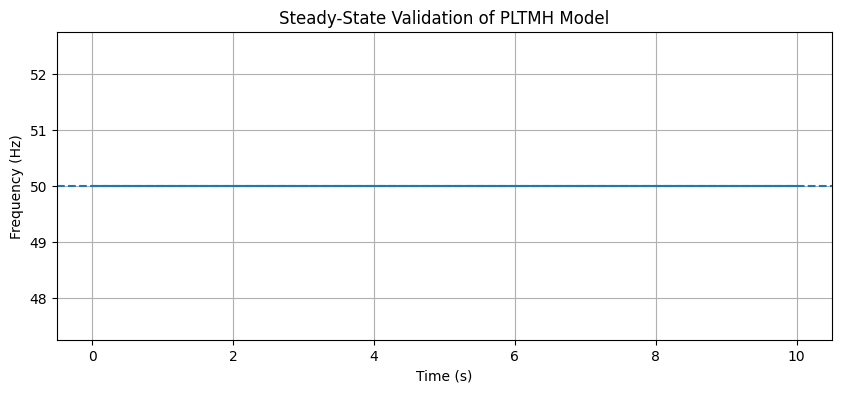

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(
    df_balanced["time_s"],
    df_balanced["frequency_hz"]
)

plt.axhline(
    params.nominal_frequency_hz,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Steady-State Validation of PLTMH Model")
plt.grid(True)

plt.show()

In [ ]:
pm_profile = constant_profile(0.80)

load_drop_profile = step_profile(
    before=0.80,
    after=0.75,
    t_step=5.0
)

df_load_drop = simulate_plant(
    params=params,
    pm_cmd_profile=pm_profile,
    pe_profile=load_drop_profile,
    t_end_s=15.0,
    dt_s=0.01,
    initial_pm_pu=0.80,
    initial_omega_pu=1.0,
)

df_load_drop.head()

,time_s,pm_cmd_pu,pm_pu,pe_pu,omega_pu,frequency_hz,delta_f_hz,power_mismatch_pu,power_mismatch_kw,rocof_hz_s
0,0.00,0.8,0.8,0.8,1.0,50.0,0.0,0.0,0.0,0.0
1,0.01,0.8,0.8,0.8,1.0,50.0,0.0,0.0,0.0,0.0
2,0.02,0.8,0.8,0.8,1.0,50.0,0.0,0.0,0.0,0.0
3,0.03,0.8,0.8,0.8,1.0,50.0,0.0,0.0,0.0,0.0
4,0.04,0.8,0.8,0.8,1.0,50.0,0.0,0.0,0.0,0.0


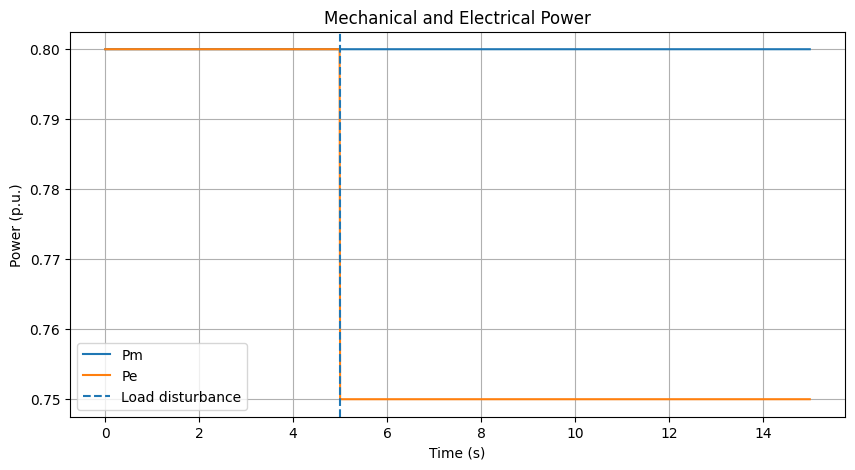

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_load_drop["time_s"],
    df_load_drop["pm_pu"],
    label="Pm"
)

plt.plot(
    df_load_drop["time_s"],
    df_load_drop["pe_pu"],
    label="Pe"
)

plt.axvline(
    5.0,
    linestyle="--",
    label="Load disturbance"
)

plt.xlabel("Time (s)")
plt.ylabel("Power (p.u.)")
plt.title("Mechanical and Electrical Power")
plt.legend()
plt.grid(True)

plt.show()

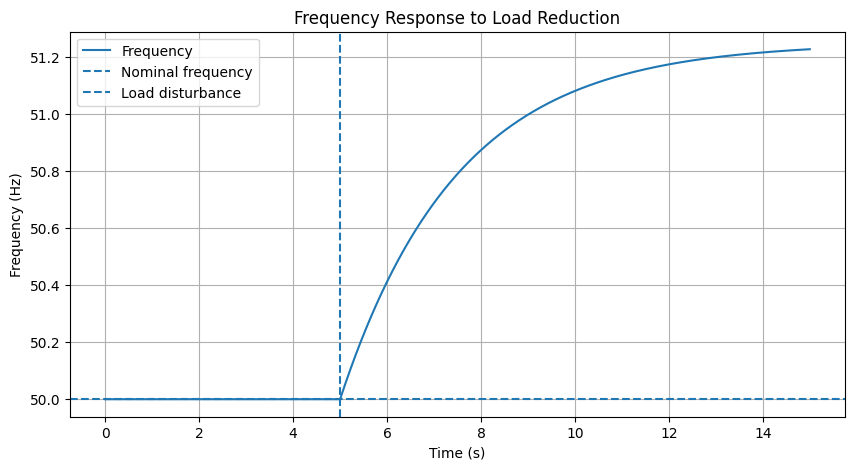

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_load_drop["time_s"],
    df_load_drop["frequency_hz"],
    label="Frequency"
)

plt.axhline(
    50.0,
    linestyle="--",
    label="Nominal frequency"
)

plt.axvline(
    5.0,
    linestyle="--",
    label="Load disturbance"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Frequency Response to Load Reduction")
plt.legend()
plt.grid(True)

plt.show()

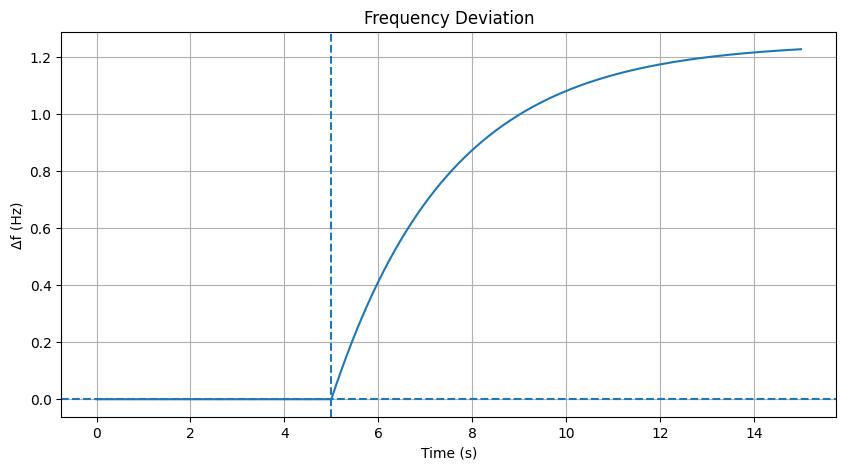

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_load_drop["time_s"],
    df_load_drop["delta_f_hz"]
)

plt.axhline(
    0.0,
    linestyle="--"
)

plt.axvline(
    5.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Δf (Hz)")
plt.title("Frequency Deviation")
plt.grid(True)

plt.show()

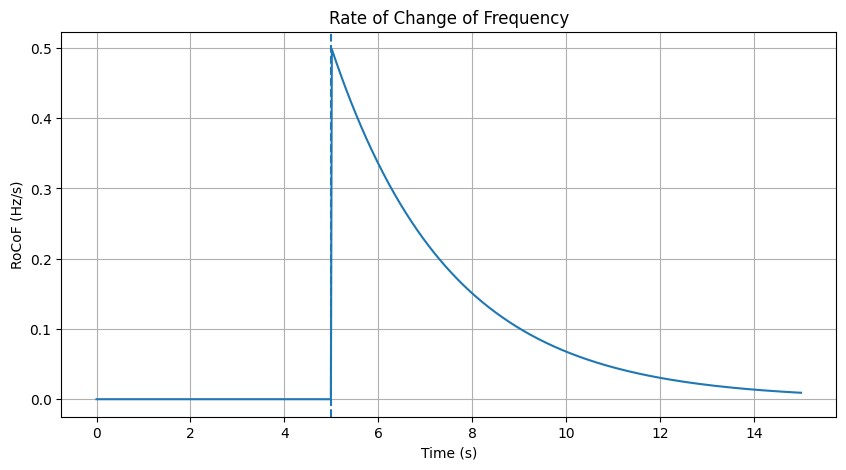

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_load_drop["time_s"],
    df_load_drop["rocof_hz_s"]
)

plt.axvline(
    5.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("RoCoF (Hz/s)")
plt.title("Rate of Change of Frequency")
plt.grid(True)

plt.show()

In [ ]:
f = df_load_drop[
    "frequency_hz"
].to_numpy()

delta_f = df_load_drop[
    "delta_f_hz"
].to_numpy()

rocof = df_load_drop[
    "rocof_hz_s"
].to_numpy()

print("=== METRIK DASAR ===")

print(
    f"Minimum frequency : "
    f"{np.min(f):.4f} Hz"
)

print(
    f"Maximum frequency : "
    f"{np.max(f):.4f} Hz"
)

print(
    f"Maximum |Δf|      : "
    f"{np.max(np.abs(delta_f)):.4f} Hz"
)

print(
    f"Maximum |RoCoF|   : "
    f"{np.max(np.abs(rocof)):.4f} Hz/s"
)

print(
    f"Final frequency   : "
    f"{f[-1]:.4f} Hz"
)

=== METRIK DASAR ===
Minimum frequency : 50.0000 Hz
Maximum frequency : 51.2271 Hz
Maximum |Δf|      : 1.2271 Hz
Maximum |RoCoF|   : 0.4980 Hz/s
Final frequency   : 51.2271 Hz


In [ ]:
f_before = df_load_drop.loc[
    df_load_drop["time_s"] < 5.0,
    "frequency_hz"
].iloc[-1]

f_after = df_load_drop[
    "frequency_hz"
].iloc[-1]

print("Frequency before disturbance :", f_before)
print("Frequency after disturbance  :", f_after)

assert f_after > f_before

print(
    "PASS: penurunan beban menyebabkan "
    "kenaikan frekuensi."
)

Frequency before disturbance : 50.0
Frequency after disturbance  : 51.22710546418558
PASS: penurunan beban menyebabkan kenaikan frekuensi.


In [ ]:
load_increase_profile = step_profile(
    before=0.80,
    after=0.85,
    t_step=5.0
)

df_load_increase = simulate_plant(
    params=params,
    pm_cmd_profile=constant_profile(0.80),
    pe_profile=load_increase_profile,
    t_end_s=15.0,
    dt_s=0.01,
    initial_pm_pu=0.80,
    initial_omega_pu=1.0,
)

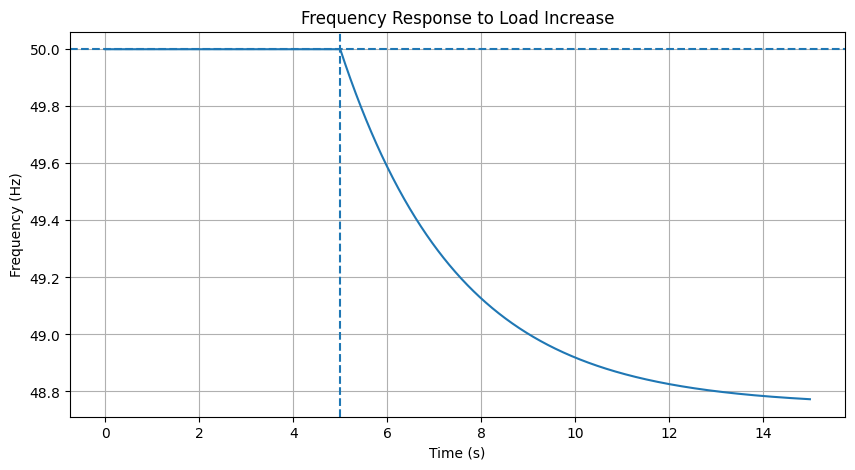

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_load_increase["time_s"],
    df_load_increase["frequency_hz"]
)

plt.axhline(
    50.0,
    linestyle="--"
)

plt.axvline(
    5.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Frequency Response to Load Increase")
plt.grid(True)

plt.show()

In [ ]:
assert (
    df_load_increase[
        "frequency_hz"
    ].iloc[-1]
    <
    params.nominal_frequency_hz
)

print(
    "PASS: kenaikan beban menyebabkan "
    "penurunan frekuensi."
)

PASS: kenaikan beban menyebabkan penurunan frekuensi.


In [ ]:
from dataclasses import replace

H_values = [
    1.5,
    2.5,
    4.0
]

results_H = {}

for H_value in H_values:

    params_H = replace(
        params,
        inertia_constant_s=H_value
    )

    result = simulate_plant(
        params=params_H,
        pm_cmd_profile=constant_profile(0.80),
        pe_profile=step_profile(
            before=0.80,
            after=0.75,
            t_step=5.0
        ),
        t_end_s=10.0,
        dt_s=0.01,
        initial_pm_pu=0.80,
        initial_omega_pu=1.0,
    )

    results_H[H_value] = result

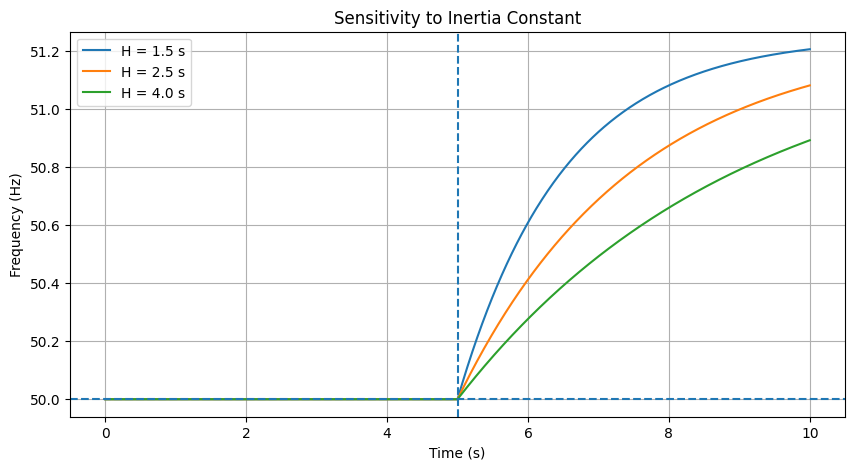

In [ ]:
plt.figure(figsize=(10, 5))

for H_value, result in results_H.items():

    plt.plot(
        result["time_s"],
        result["frequency_hz"],
        label=f"H = {H_value} s"
    )

plt.axhline(
    50.0,
    linestyle="--"
)

plt.axvline(
    5.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Sensitivity to Inertia Constant")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("=== INERTIA SENSITIVITY ===")

for H_value, result in results_H.items():

    max_rocof = np.max(
        np.abs(
            result["rocof_hz_s"]
        )
    )

    print(
        f"H = {H_value:.1f} s "
        f"-> max |RoCoF| = "
        f"{max_rocof:.4f} Hz/s"
    )

=== INERTIA SENSITIVITY ===
H = 1.5 s -> max |RoCoF| = 0.8278 Hz/s
H = 2.5 s -> max |RoCoF| = 0.4980 Hz/s
H = 4.0 s -> max |RoCoF| = 0.3118 Hz/s


In [ ]:
%%writefile /content/PLTMH-ELC-QLSTM/tests/test_plant_model.py

import numpy as np

from src.plant import (
    PlantParams,
    nominal_flow_m3_s,
    mechanical_power_w,
    constant_profile,
    step_profile,
    simulate_plant,
)


def test_nominal_hydraulic_power():

    params = PlantParams()

    q_nom = nominal_flow_m3_s(
        params
    )

    pm_kw = (
        mechanical_power_w(
            q_nom,
            params
        )
        / 1000.0
    )

    assert np.isclose(
        pm_kw,
        params.rated_power_kw,
        rtol=1e-6
    )


def test_equilibrium_frequency():

    params = PlantParams()

    result = simulate_plant(
        params=params,
        pm_cmd_profile=constant_profile(
            0.80
        ),
        pe_profile=constant_profile(
            0.80
        ),
        t_end_s=5.0,
        dt_s=0.01,
        initial_pm_pu=0.80,
    )

    max_error = np.max(
        np.abs(
            result["frequency_hz"]
            - params.nominal_frequency_hz
        )
    )

    assert max_error < 1e-6


def test_load_drop_increases_frequency():

    params = PlantParams()

    result = simulate_plant(
        params=params,
        pm_cmd_profile=constant_profile(
            0.80
        ),
        pe_profile=step_profile(
            0.80,
            0.75,
            2.0
        ),
        t_end_s=5.0,
        dt_s=0.01,
        initial_pm_pu=0.80,
    )

    assert (
        result[
            "frequency_hz"
        ].iloc[-1]
        >
        params.nominal_frequency_hz
    )


def test_load_increase_decreases_frequency():

    params = PlantParams()

    result = simulate_plant(
        params=params,
        pm_cmd_profile=constant_profile(
            0.80
        ),
        pe_profile=step_profile(
            0.80,
            0.85,
            2.0
        ),
        t_end_s=5.0,
        dt_s=0.01,
        initial_pm_pu=0.80,
    )

    assert (
        result[
            "frequency_hz"
        ].iloc[-1]
        <
        params.nominal_frequency_hz
    )

Overwriting /content/PLTMH-ELC-QLSTM/tests/test_plant_model.py


In [ ]:
!pytest -q tests/test_plant_model.py

....                                                                     [100%]
4 passed in 1.19s


In [ ]:
from pathlib import Path

results_dir = (
    Path("/content/PLTMH-ELC-QLSTM")
    / "results"
    / "plant_validation"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(results_dir)

/content/PLTMH-ELC-QLSTM/results/plant_validation


In [ ]:
df_balanced.to_csv(
    results_dir
    / "steady_state_validation.csv",
    index=False
)

df_load_drop.to_csv(
    results_dir
    / "load_drop_validation.csv",
    index=False
)

df_load_increase.to_csv(
    results_dir
    / "load_increase_validation.csv",
    index=False
)

print("Hasil validasi berhasil disimpan.")

Hasil validasi berhasil disimpan.


In [ ]:
!find /content/PLTMH-ELC-QLSTM/results/plant_validation -maxdepth 1 -type f

/content/PLTMH-ELC-QLSTM/results/plant_validation/load_increase_validation.csv
/content/PLTMH-ELC-QLSTM/results/plant_validation/load_drop_validation.csv
/content/PLTMH-ELC-QLSTM/results/plant_validation/steady_state_validation.csv


In [ ]:
!find /content/PLTMH-ELC-QLSTM -maxdepth 3 -type f | sort

/content/PLTMH-ELC-QLSTM/config/controller.yaml
/content/PLTMH-ELC-QLSTM/config/experiment.yaml
/content/PLTMH-ELC-QLSTM/config/plant.yaml
/content/PLTMH-ELC-QLSTM/config/qlstm.yaml
/content/PLTMH-ELC-QLSTM/docs/equations.md
/content/PLTMH-ELC-QLSTM/docs/methodology.md
/content/PLTMH-ELC-QLSTM/.git/config
/content/PLTMH-ELC-QLSTM/.git/description
/content/PLTMH-ELC-QLSTM/.git/HEAD
/content/PLTMH-ELC-QLSTM/.git/hooks/applypatch-msg.sample
/content/PLTMH-ELC-QLSTM/.git/hooks/commit-msg.sample
/content/PLTMH-ELC-QLSTM/.git/hooks/fsmonitor-watchman.sample
/content/PLTMH-ELC-QLSTM/.git/hooks/post-update.sample
/content/PLTMH-ELC-QLSTM/.git/hooks/pre-applypatch.sample
/content/PLTMH-ELC-QLSTM/.git/hooks/pre-commit.sample
/content/PLTMH-ELC-QLSTM/.git/hooks/pre-merge-commit.sample
/content/PLTMH-ELC-QLSTM/.git/hooks/prepare-commit-msg.sample
/content/PLTMH-ELC-QLSTM/.git/hooks/pre-push.sample
/content/PLTMH-ELC-QLSTM/.git/hooks/pre-rebase.sample
/content/PLTMH-ELC-QLSTM/.git/hooks/pre-receive

In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	pytest.ini
	src/__init__.py
	src/plant/__init__.py
	src/plant/microhydro_plant.py
	tests/test_plant_model.py

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!cat .gitignore

__pycache__/
*.pyc
.ipynb_checkpoints/

data/raw/
data/processed/

checkpoints/
results/

*.pt
*.pth
*.pkl
*.parquet

.env


In [ ]:
!git add src/plant
!git add tests/test_plant_model.py

In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   src/plant/__init__.py
	new file:   src/plant/microhydro_plant.py
	new file:   tests/test_plant_model.py

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	pytest.ini
	src/__init__.py



In [ ]:
!git commit -m "Add reduced-order microhydro plant model"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@2979c5a842b1.(none)')


In [ ]:
!git push origin main

In [ ]:
from google.colab import userdata

github_token = userdata.get("GITHUB_TOKEN")

print("GitHub token berhasil dibaca dari Colab Secrets.")

GitHub token berhasil dibaca dari Colab Secrets.


In [ ]:
import subprocess

result = subprocess.run(
    [
        "gh",
        "auth",
        "login",
        "--hostname",
        "github.com",
        "--with-token"
    ],
    input=github_token,
    text=True,
    capture_output=True
)

print(result.stdout)

if result.returncode == 0:
    print("PASS: autentikasi GitHub berhasil.")
else:
    print("Autentikasi gagal:")
    print(result.stderr)


PASS: autentikasi GitHub berhasil.


In [ ]:
!gh auth setup-git

In [ ]:
!gh auth status

github.com
  ✓ Logged in to github.com account p12Ivy0 (/root/.config/gh/hosts.yml)
  - Active account: true
  - Git operations protocol: https
  - Token: github_pat_**********************************************************************************


In [ ]:
%cd /content/PLTMH-ELC-QLSTM

[Errno 2] No such file or directory: '/content/PLTMH-ELC-QLSTM'
/content


In [ ]:
!ls -la /content

total 16
drwxr-xr-x 1 root root 4096 Aug 24 13:21 .
drwxr-xr-x 1 root root 4096 Sep  5 03:08 ..
drwxr-xr-x 4 root root 4096 Aug 24 13:21 .config
drwxr-xr-x 1 root root 4096 Aug 24 13:21 sample_data


In [ ]:
%cd /content
!git clone https://github.com/p12Ivy0/PLTMH-ELC-QLSTM

/content
Cloning into 'PLTMH-ELC-QLSTM'...
remote: Enumerating objects: 181, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 181 (delta 13), reused 10 (delta 10), pack-reused 165 (from 1)
Receiving objects: 100% (181/181), 51.88 KiB | 5.76 MiB/s, done.
Resolving deltas: 100% (75/75), done.


In [ ]:
%cd /content/PLTMH-ELC-QLSTM

/content/PLTMH-ELC-QLSTM


In [ ]:
!pwd
!git status

/content/PLTMH-ELC-QLSTM
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
!ls -la src/plant
!ls -la tests

total 28
drwxr-xr-x 2 root root 4096 Sep  5 04:04 .
drwxr-xr-x 8 root root 4096 Sep  5 04:04 ..
-rw-r--r-- 1 root root    1 Sep  5 04:04 consumer_load.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 dump_load.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 elc.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 synchronous_generator.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 turbine.py
total 24
drwxr-xr-x 2 root root 4096 Sep  5 04:04 .
drwxr-xr-x 8 root root 4096 Sep  5 04:04 ..
-rw-r--r-- 1 root root    1 Sep  5 04:04 test_elc.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 test_generator.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 test_pi.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 test_turbine.py


In [ ]:
%cd /content/PLTMH-ELC-QLSTM
!git status

/content/PLTMH-ELC-QLSTM
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
!ls -la src

total 32
drwxr-xr-x 8 root root 4096 Sep  5 04:04 .
drwxr-xr-x 8 root root 4096 Sep  5 04:04 ..
drwxr-xr-x 2 root root 4096 Sep  5 04:04 control
drwxr-xr-x 2 root root 4096 Sep  5 04:04 data
drwxr-xr-x 2 root root 4096 Sep  5 04:04 evaluation
drwxr-xr-x 2 root root 4096 Sep  5 04:04 models
drwxr-xr-x 2 root root 4096 Sep  5 04:04 plant
drwxr-xr-x 2 root root 4096 Sep  5 04:04 simulation


In [ ]:
!ls -la src/plant

total 32
drwxr-xr-x 2 root root 4096 Sep  5 04:15 .
drwxr-xr-x 8 root root 4096 Sep  5 04:04 ..
-rw-r--r-- 1 root root    1 Sep  5 04:04 consumer_load.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 dump_load.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 elc.py
-rw-r--r-- 1 root root    1 Sep  5 04:15 microhydro_plant.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 synchronous_generator.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 turbine.py


In [ ]:
!test -f src/__init__.py && echo "ADA" || echo "TIDAK ADA"

TIDAK ADA


In [ ]:
!ls -la src/plant

total 40
drwxr-xr-x 2 root root 4096 Sep  5 04:25 .
drwxr-xr-x 8 root root 4096 Sep  5 04:17 ..
-rw-r--r-- 1 root root    1 Sep  5 04:04 consumer_load.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 dump_load.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 elc.py
-rw-r--r-- 1 root root  197 Sep  5 04:25 __init__.py
-rw-r--r-- 1 root root 6092 Sep  5 04:23 microhydro_plant.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 synchronous_generator.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 turbine.py


In [ ]:
!test -f src/__init__.py && echo "ADA" || echo "TIDAK ADA"

ADA


In [ ]:
!ls -la tests

total 28
drwxr-xr-x 2 root root 4096 Sep  5 04:21 .
drwxr-xr-x 8 root root 4096 Sep  5 04:04 ..
-rw-r--r-- 1 root root    1 Sep  5 04:04 test_elc.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 test_generator.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 test_pi.py
-rw-r--r-- 1 root root 1974 Sep  5 04:27 test_plant_model.py
-rw-r--r-- 1 root root    1 Sep  5 04:04 test_turbine.py


In [ ]:
%%writefile /content/PLTMH-ELC-QLSTM/pytest.ini
[pytest]
pythonpath = .
testpaths = tests

Writing /content/PLTMH-ELC-QLSTM/pytest.ini


In [ ]:
!cat pytest.ini

[pytest]
pythonpath = .
testpaths = tests


In [ ]:
%cd /content/PLTMH-ELC-QLSTM
!PYTHONPATH=/content/PLTMH-ELC-QLSTM python -m pytest -q tests/test_plant_model.py

/content/PLTMH-ELC-QLSTM
....                                                                     [100%]
4 passed in 2.06s


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	pytest.ini
	src/__init__.py
	src/plant/__init__.py
	src/plant/microhydro_plant.py
	tests/test_plant_model.py

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!git add src/__init__.py
!git add src/plant/__init__.py
!git add src/plant/microhydro_plant.py
!git add tests/test_plant_model.py
!git add pytest.ini

In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   pytest.ini
	new file:   src/__init__.py
	new file:   src/plant/__init__.py
	new file:   src/plant/microhydro_plant.py
	new file:   tests/test_plant_model.py



In [ ]:
!git push origin main

Everything up-to-date


In [ ]:
!git clone https://github.com/p12Ivy0/PLTMH-ELC-QLSTM

Cloning into 'PLTMH-ELC-QLSTM'...
remote: Enumerating objects: 181, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 181 (delta 13), reused 10 (delta 10), pack-reused 165 (from 1)
Receiving objects: 100% (181/181), 51.88 KiB | 5.76 MiB/s, done.
Resolving deltas: 100% (75/75), done.


In [ ]:
%cd /content/PLTMH-ELC-QLSTM

/content/PLTMH-ELC-QLSTM


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   pytest.ini
	new file:   src/__init__.py
	new file:   src/plant/__init__.py
	new file:   src/plant/microhydro_plant.py
	new file:   tests/test_plant_model.py

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	PLTMH-ELC-QLSTM/



In [ ]:
!git commit -m "Add reduced-order microhydro plant model and tests"

[main 85c366f] Add reduced-order microhydro plant model and tests
 5 files changed, 441 insertions(+)
 create mode 100644 pytest.ini
 create mode 100644 src/__init__.py
 create mode 100644 src/plant/__init__.py
 create mode 100644 src/plant/microhydro_plant.py
 create mode 100644 tests/test_plant_model.py


In [ ]:
!git config --global user.name "p12Ivy0"
!git config --global user.email "ypriyogunos@gmail.com"

In [ ]:
!git push origin main

Enumerating objects: 14, done.
Counting objects: 100% (14/14), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (10/10), 3.17 KiB | 1.06 MiB/s, done.
Total 10 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 4 local objects.
To https://github.com/p12Ivy0/PLTMH-ELC-QLSTM
   2ad6e3b..85c366f  main -> main


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	PLTMH-ELC-QLSTM/

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
%cd /content/PLTMH-ELC-QLSTM

/content/PLTMH-ELC-QLSTM


In [ ]:
!rm -rf /content/PLTMH-ELC-QLSTM/PLTMH-ELC-QLSTM

In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
